# Constraint-Aware Parameter Calibration (Winter Wheat)

This example shows how to calibrate Lintul5 parameters with
**`torchcrop.calibration`** under three kinds of constraint:

- **Bounds & type** — a scalar such as `TSUM1` confined to a physical range,
  or an integer-valued parameter.
- **DVS-table ordinates** — calibrating the _value_ of a table entry at a
  specific DVS stage (e.g. RUE at DVS 0) while the DVS positions stay fixed.
- **Ordering** — enforcing ascending / descending relationships among a set of
  table entries (e.g. a monotonically declining RUE curve).

Every constraint is enforced by a **differentiable reparameterization**: the
optimizer works in an _unconstrained_ latent space and a bijection maps it onto
the feasible region on every step. As a result, **every iterate is feasible by
construction** — no penalty terms, no post-step clipping — and the whole loop
stays end-to-end differentiable, so any `torch.optim` optimizer just works.


In [1]:
import torch
import matplotlib.pyplot as plt

from torchcrop import Lintul5Model, ParameterSpec, ConstraintGroup, CalibrationManager
from torchcrop.calibration import load_calibration_config
from torchcrop.parameters.crop_params import CropParameters
from torchcrop.utils.io import make_constant_weather

torch.manual_seed(0)
DTYPE = torch.float64  # calibrate in double precision for clean gradients

## 1. A twin experiment

To make recovery verifiable, we run a _twin experiment_: build a "true" model
with **known** parameter values, generate synthetic observations from it, then
see whether calibration recovers those values starting from a deliberately
wrong initial guess.

We fit both the **final yield** and the **LAI trajectory** — the LAI curve
carries phenological timing information that makes `TSUM1` identifiable, while
yield magnitude pins down RUE.


In [2]:
weather = make_constant_weather(batch_size=1, n_days=120, dtype=DTYPE)

def build_model(tsum1=900.0, rue0=3.0):
    cp = CropParameters().to(dtype=DTYPE)
    cp.tsum1 = torch.tensor(tsum1, dtype=DTYPE)
    ruetb = cp.ruetb.clone()
    ruetb[0, 1] = rue0          # RUE at DVS 0.0
    cp.ruetb = ruetb
    return Lintul5Model(crop_params=cp).double()

# Ground truth
TRUE_TSUM1, TRUE_RUE0 = 820.0, 2.70
truth = build_model(tsum1=TRUE_TSUM1, rue0=TRUE_RUE0)
with torch.no_grad():
    ref = truth(weather, start_doy=60)
obs_yield = ref.yield_.detach()
obs_lai = ref.lai.detach()
print(f"observed yield = {float(obs_yield):.1f} g/m^2, peak LAI = {float(obs_lai.max()):.2f}")

observed yield = 744.1 g/m^2, peak LAI = 4.32


## 2. Declare the calibration problem

A calibration problem is pure _data_: a list of `ParameterSpec` (what is free,
its bounds and type) and optional `ConstraintGroup`s (ordering relations).
Targets are addressed by dotted path — scalars as `"crop.tsum1"`, and table
ordinates as `"crop.ruetb@0.0"` (the y-value of the row at DVS 0.0).

We start from a **wrong** initial guess (`TSUM1=1000`, `RUE0=3.0`) and let the
manager seed its latents from those values.


In [3]:
model = build_model(tsum1=1000.0, rue0=3.0)  # deliberately off

specs = [
    ParameterSpec("crop.tsum1",    bounds=(700.0, 1100.0), init=1000.0),
    ParameterSpec("crop.ruetb@0.0", bounds=(2.0, 3.5),     init=3.0),
]
cal = CalibrationManager(model, specs)

print("initial (materialized) values:")
for k, v in cal.named_values().items():
    print(f"  {k:18s} = {v:.3f}")

initial (materialized) values:
  crop.tsum1         = 1000.000
  crop.ruetb@0.0     = 3.000


## 3. Optimize

The loop is standard PyTorch. The only addition is `cal.materialize()`, which
writes the constrained values into the model's parameter tensors **before** the
forward pass. The optimizer sees only `cal.parameters()` — the latent
variables — so the physical parameters can never leave their bounds.


In [4]:
optimizer = torch.optim.Adam(cal.parameters(), lr=0.05)

history = {"loss": [], "tsum1": [], "rue0": []}

for step in range(100):
    optimizer.zero_grad()

    cal.materialize()
    out = model(weather, start_doy=60)

    loss = (
        (out.yield_ - obs_yield).pow(2).mean() / obs_yield.pow(2)
        + (out.lai - obs_lai).pow(2).mean()
    )

    loss.backward()
    optimizer.step()

    vals = cal.named_values()

    history["loss"].append(float(loss))
    history["tsum1"].append(vals["crop.tsum1"])
    history["rue0"].append(vals["crop.ruetb@0.0"])

    print(
        f"step={step:03d} | "
        f"loss={loss.item():.6f} | "
        f"tsum1={vals['crop.tsum1']:.4f} | "
        f"rue0={vals['crop.ruetb@0.0']:.4f}"
    )

print(f"\nfinal loss = {history['loss'][-1]:.3e}")

step=000 | loss=1.107609 | tsum1=996.2033 | rue0=2.9832
step=001 | loss=1.077642 | tsum1=992.3133 | rue0=2.9661
step=002 | loss=1.048093 | tsum1=988.3381 | rue0=2.9488
step=003 | loss=0.958305 | tsum1=984.2733 | rue0=2.9313
step=004 | loss=0.928718 | tsum1=980.1182 | rue0=2.9136
step=005 | loss=0.898887 | tsum1=975.8736 | rue0=2.8957
step=006 | loss=0.869733 | tsum1=971.5541 | rue0=2.8776
step=007 | loss=0.752046 | tsum1=967.1669 | rue0=2.8594
step=008 | loss=0.723758 | tsum1=962.7111 | rue0=2.8412
step=009 | loss=0.695658 | tsum1=958.2034 | rue0=2.8228
step=010 | loss=0.616272 | tsum1=953.6413 | rue0=2.8045
step=011 | loss=0.589658 | tsum1=949.0262 | rue0=2.7861
step=012 | loss=0.563207 | tsum1=944.3626 | rue0=2.7679
step=013 | loss=0.489699 | tsum1=939.6783 | rue0=2.7497
step=014 | loss=0.465659 | tsum1=934.9737 | rue0=2.7316
step=015 | loss=0.442047 | tsum1=930.2497 | rue0=2.7138
step=016 | loss=0.419209 | tsum1=925.5310 | rue0=2.6961
step=017 | loss=0.354625 | tsum1=920.8268 | rue0

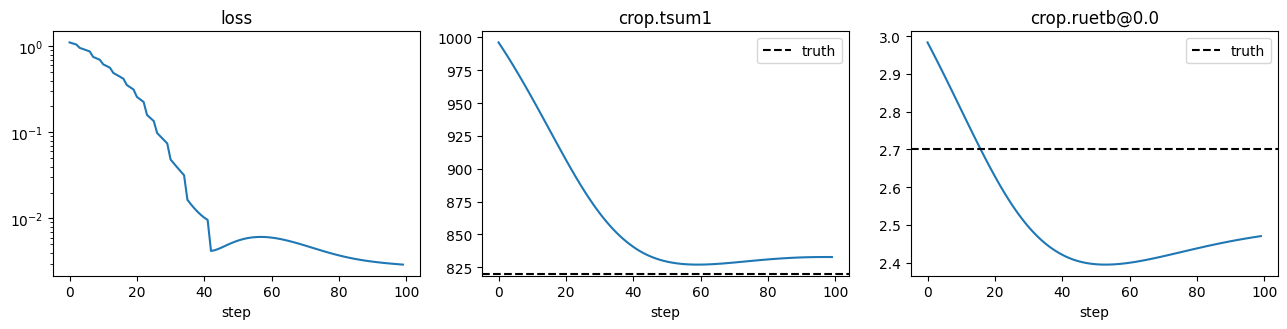

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].semilogy(history["loss"]);            ax[0].set_title("loss");  ax[0].set_xlabel("step")
ax[1].plot(history["tsum1"]);               ax[1].axhline(TRUE_TSUM1, ls="--", c="k", label="truth")
ax[1].set_title("crop.tsum1"); ax[1].set_xlabel("step"); ax[1].legend()
ax[2].plot(history["rue0"]);                ax[2].axhline(TRUE_RUE0, ls="--", c="k", label="truth")
ax[2].set_title("crop.ruetb@0.0"); ax[2].set_xlabel("step"); ax[2].legend()
plt.tight_layout(); plt.show()

## 4. Recovery

The calibration recovers `TSUM1` to within ~2% and pulls `RUE` toward its
true value, and — the key guarantee — every iterate stayed strictly inside
the declared bounds. (The two-parameter yield+LAI fit is mildly
underdetermined, so RUE lands close rather than exactly; adding more
observations or iterations tightens it.)


In [6]:
vals = cal.named_values()
print(f"  TSUM1 : recovered {vals['crop.tsum1']:8.2f}  | truth {TRUE_TSUM1:8.2f}")
print(f"  RUE@0 : recovered {vals['crop.ruetb@0.0']:8.3f}  | truth {TRUE_RUE0:8.3f}")

  TSUM1 : recovered   832.69  | truth   820.00
  RUE@0 : recovered    2.470  | truth    2.700


## 5. Calibrating table ordinates with an ordering constraint

A common agronomic requirement is that the **RUE curve declines** with
development stage. We can free several ordinates of `ruetb` and tie them into a
`descending` `ConstraintGroup`. The manager reconstructs the group jointly, so
`v(DVS=0) >= v(DVS=1) >= v(DVS=1.3) >= v(DVS=2)` holds for **any** latent
values — monotonicity is guaranteed, not penalized.

For an ordered group, each member's bounds must be compatible with the
ordering (here: bounds step _down_ across the curve).


In [7]:
rue_model = build_model()
rue_specs = [
    ParameterSpec("crop.ruetb@0.0", bounds=(2.8, 3.5)),
    ParameterSpec("crop.ruetb@1.0", bounds=(2.0, 3.2)),
    ParameterSpec("crop.ruetb@1.3", bounds=(1.0, 2.6)),
    ParameterSpec("crop.ruetb@2.0", bounds=(0.2, 1.2)),
]
rue_group = ConstraintGroup(tuple(s.name for s in rue_specs), order="descending")
rue_cal = CalibrationManager(rue_model, rue_specs, [rue_group])

# Sample random latents and confirm the reconstructed curve is monotone & bounded
for trial in range(5):
    rue_cal.set_flat(torch.randn(len(rue_specs), dtype=DTYPE) * 3.0)
    v = rue_cal.named_values()
    seq = [v["crop.ruetb@0.0"], v["crop.ruetb@1.0"], v["crop.ruetb@1.3"], v["crop.ruetb@2.0"]]
    monotone = all(a >= b for a, b in zip(seq, seq[1:]))
    print(f"trial {trial}: {[round(s, 3) for s in seq]}  descending={monotone}")

trial 0: [3.493, 2.352, 1.002, 0.879]  descending=True
trial 1: [2.826, 2.012, 1.78, 1.125]  descending=True
trial 2: [2.873, 2.2, 1.172, 0.815]  descending=True
trial 3: [2.85, 2.82, 1.062, 0.709]  descending=True
trial 4: [2.908, 2.685, 1.103, 0.21]  descending=True


## 6. Integer-valued parameters

Set `kind="integer"` to keep a parameter integral in the forward pass while
still receiving a gradient through a straight-through estimator (useful for
count-like or day-resolved parameters). The value used by the model is rounded;
the latent is nudged continuously.


In [8]:
int_model = build_model()
int_cal = CalibrationManager(
    int_model,
    [ParameterSpec("crop.tsumem", bounds=(80.0, 160.0), kind="integer", init=110.0)],
)
int_cal.set_flat(torch.tensor([0.37], dtype=DTYPE))
materialized = int_cal.named_values()["crop.tsumem"]
print(f"materialized tsumem = {materialized}  (integral: {materialized == round(materialized)})")

materialized tsumem = 127.0  (integral: True)


## 7. The same problem as YAML

Calibration setups can live next to crop presets as declarative configuration,
keyed on the same dotted target paths.


In [9]:
config = {
    "parameters": {
        "crop.tsum1":     {"bounds": [700, 1100]},
        "crop.ruetb@0.0": {"bounds": [2.8, 3.5]},
        "crop.ruetb@1.0": {"bounds": [2.0, 3.2]},
    },
    "constraints": [
        {"members": ["crop.ruetb@0.0", "crop.ruetb@1.0"], "order": "descending"},
    ],
}
specs2, groups2 = load_calibration_config(config)
print(f"{len(specs2)} specs, {len(groups2)} constraint group(s)")
CalibrationManager(build_model(), specs2, groups2)  # ready to optimize

3 specs, 1 constraint group(s)


CalibrationManager(
  (_latents): ParameterDict(
      (crop__tsum1): Parameter containing: [torch.DoubleTensor of size ]
      (crop__ruetb__0__0): Parameter containing: [torch.DoubleTensor of size ]
      (crop__ruetb__1__0): Parameter containing: [torch.DoubleTensor of size ]
  )
)

## 8. Gradient-free / Bayesian bridge

Because the latent space is unconstrained, the same problem definition can be
driven by a derivative-free optimizer (CMA-ES, scipy, NSGA-II). `flatten()`
exposes the latent vector and `set_flat()` writes a candidate back — the bridge
an outer optimization loop needs.


In [10]:
z = cal.flatten()
print("latent vector:", [round(float(x), 3) for x in z])
cal.set_flat(z)  # round-trips
print("round-trip ok:", torch.allclose(cal.flatten(), z))

latent vector: [-0.784, -0.7]
round-trip ok: True


## Summary

`torchcrop.calibration` adds bounded, typed, table-aware and order-constrained
calibration on top of the differentiable Lintul5 forward model:

| Need                                     | Mechanism                                             |
| ---------------------------------------- | ----------------------------------------------------- |
| Bounded scalar (`TSUM1 ∈ [1000, 2000]`)  | `affine_sigmoid` reparameterization                   |
| Integer / continuous type                | straight-through rounding                             |
| DVS-table **ordinate** (positions fixed) | `"crop.fltb@0.5"` targets, table rebuilt non-in-place |
| Ascending / descending / free ordering   | joint monotone reconstruction                         |
| Declarative setup                        | YAML / dict config                                    |
| Gradient-free optimizers                 | `flatten()` / `set_flat()` latent bridge              |

All of it is enforced _by construction_ and stays differentiable, so it
composes with the rest of torchcrop (hybrid ML residuals, batched simulation,
GPU execution) without changes to any process module.
